In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian1DKernel

from sparcl.client import SparclClient
from dl import queryClient as qc

import time

In [2]:
zmin = 1.5
zmax = 1.8

n_plot = 10
max_intentos = 5
pausa = 10

lambda_min = 1200
lambda_max = 3500

In [3]:
client = SparclClient(
    connect_timeout=60,
    read_timeout=5400
)

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [4]:
def recuperar_espectro(specid, inc, dataset='DESI-DR1',
                        max_intentos=5, pausa=10):

    for intento in range(max_intentos):

        try:
            res = client.retrieve_by_specid(
                specid_list=[int(specid)],
                include=inc,
                dataset_list=[dataset]
            )
            return res

        except Exception as e:
            print(f"Intento {intento + 1}/{max_intentos} falló para specid = {specid}")
            print(type(e).__name__, e)

            if intento < max_intentos - 1:
                print(f"Esperando {pausa} segundos antes de volver a intentar...")
                time.sleep(pausa)

    print(f"No se pudo recuperar specid = {specid}")
    return None

In [5]:
query = f"""
        SELECT zp.targetid, zp.z
        FROM desi_dr1.zpix AS zp
        WHERE (zp.survey = 'main')
          AND (zp.spectype = 'QSO')
          AND zp.main_primary
          AND (zp.z BETWEEN {zmin} AND {zmax})
          AND (zp.random_id BETWEEN 0. AND 0.1)
        """

zpix_cat = qc.query(sql=query, fmt='table')

zpix_cat

targetid,z
str17,float64
39632941956992987,1.680962517891546
39627580705345535,1.748952832637965
39627875699131968,1.685160400026306
39628329174699835,1.792617116282491
39628051390138743,1.556400777481888
39633418748693123,1.76121944536782
39627663668676065,1.521960174177043
39627788008818070,1.577121672762571
39628104561332008,1.629348025944537


In [6]:
targetid = zpix_cat['targetid'].data.tolist()
z_catalog = zpix_cat['z'].data.tolist()

print(f"Número de objetos encontrados con {zmin} <= z <= {zmax}: {len(targetid)}")

if len(targetid) > 0:
    print("Primeros redshifts encontrados:")
    print(z_catalog[:10])

Número de objetos encontrados con 1.5 <= z <= 1.8: 293
Primeros redshifts encontrados:
[1.680962517891546, 1.748952832637965, 1.685160400026306, 1.792617116282491, 1.556400777481888, 1.76121944536782, 1.521960174177043, 1.577121672762571, 1.629348025944537, 1.525850890380243]


In [7]:
inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype',
       'specprimary', 'survey', 'program', 'targetid',
       'redshift_warning']

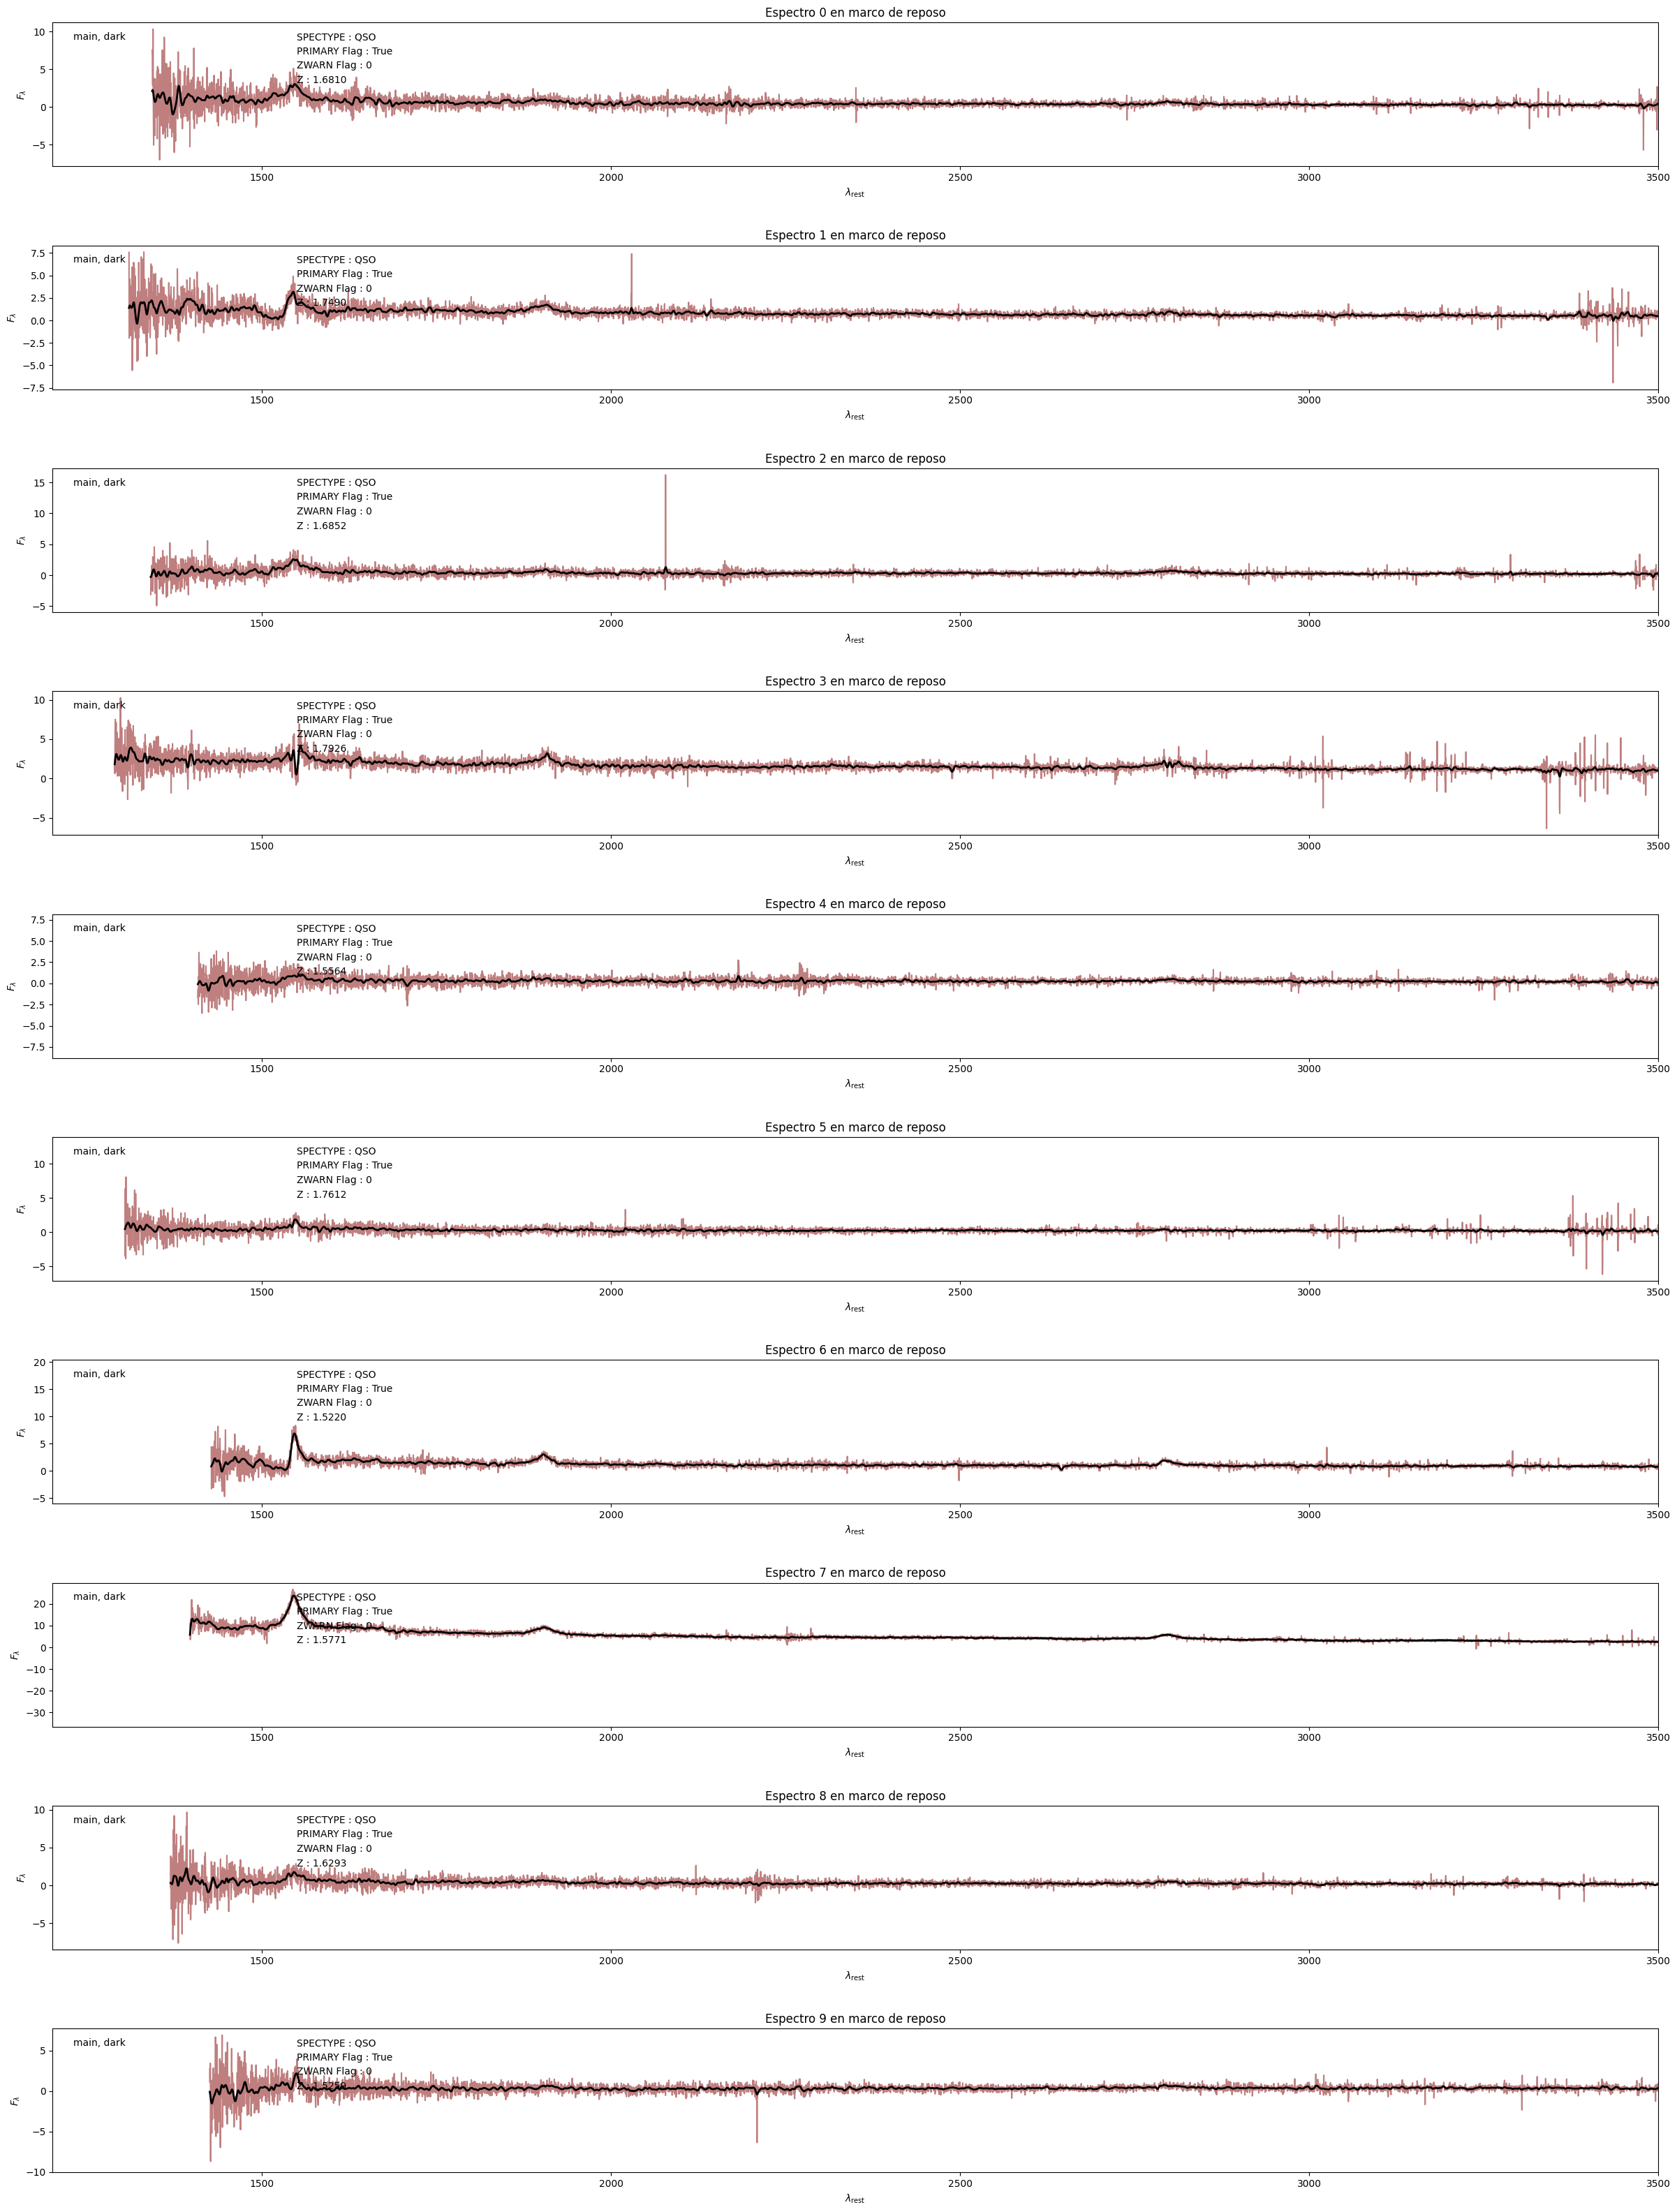

In [8]:
n = min(n_plot, len(targetid))

if n == 0:
    print("No se encontraron objetos en ese intervalo de redshift.")

else:

    fig, ax = plt.subplots(n, 1, figsize=(25, 4*n))

    if n == 1:
        ax = [ax]

    for jj in range(n):

        res = recuperar_espectro(
            specid=targetid[jj],
            inc=inc,
            dataset='DESI-DR1',
            max_intentos=max_intentos,
            pausa=pausa
        )

        if res is None:
            ax[jj].set_title(f"Falló la descarga del espectro {jj}")
            continue

        try:
            records = res.records

            survey = records[0].survey
            program = records[0].program
            spectype = records[0].spectype
            primary_flag = records[0].specprimary
            zwarn_flag = records[0].redshift_warning
            redshift = records[0].redshift

            lam_obs = records[0].wavelength
            flam_obs = records[0].flux

            lam_rest = lam_obs / (1.0 + redshift)
            flam_rest = flam_obs

            flam_smooth = convolve(flam_rest, Gaussian1DKernel(5))

            ax[jj].plot(lam_rest, flam_rest, color='maroon', alpha=0.5)
            ax[jj].plot(lam_rest, flam_smooth, color='k', lw=2.0)

            ax[jj].set(
                xlim=[lambda_min, lambda_max],
                xlabel=r'$\lambda_{\rm rest}$',
                ylabel=r'$F_{\lambda}$'
            )

            trans = ax[jj].get_xaxis_transform()

            x_text_1 = lambda_min + 30
            x_text_2 = lambda_min + 350

            ax[jj].annotate(f'{survey}, {program}',
                            xy=(x_text_1, 0.88),
                            xycoords=trans,
                            fontsize=10)

            ax[jj].annotate(f'SPECTYPE : {spectype}',
                            xy=(x_text_2, 0.88),
                            xycoords=trans,
                            fontsize=10)

            ax[jj].annotate(f'PRIMARY Flag : {primary_flag}',
                            xy=(x_text_2, 0.78),
                            xycoords=trans,
                            fontsize=10)

            ax[jj].annotate(f'ZWARN Flag : {zwarn_flag}',
                            xy=(x_text_2, 0.68),
                            xycoords=trans,
                            fontsize=10)

            ax[jj].annotate(f'Z : {redshift:.4f}',
                            xy=(x_text_2, 0.58),
                            xycoords=trans,
                            fontsize=10)

            ax[jj].set_title(f"Espectro {jj} en marco de reposo")

        except Exception as e:
            print(f"Falló el procesamiento del espectro {jj}")
            print(type(e).__name__, e)
            ax[jj].set_title(f"Falló el procesamiento del espectro {jj}")

    fig.subplots_adjust(left=0.06, right=0.98, hspace=0.55)
    plt.show()

Procesando objeto 1/100
Procesando objeto 2/100
Procesando objeto 3/100
Procesando objeto 4/100
Procesando objeto 5/100
Procesando objeto 6/100
Procesando objeto 7/100
Procesando objeto 8/100
Procesando objeto 9/100
Procesando objeto 10/100
Procesando objeto 11/100
Procesando objeto 12/100
Procesando objeto 13/100
Procesando objeto 14/100
Procesando objeto 15/100
Procesando objeto 16/100
Procesando objeto 17/100
Procesando objeto 18/100
Procesando objeto 19/100
Procesando objeto 20/100
Procesando objeto 21/100
Procesando objeto 22/100
Procesando objeto 23/100
Procesando objeto 24/100
Procesando objeto 25/100
Procesando objeto 26/100
Procesando objeto 27/100
Procesando objeto 28/100
Procesando objeto 29/100
Procesando objeto 30/100
Procesando objeto 31/100
Procesando objeto 32/100
Procesando objeto 33/100
Procesando objeto 34/100
Procesando objeto 35/100
Procesando objeto 36/100
Procesando objeto 37/100
Procesando objeto 38/100
Procesando objeto 39/100
Procesando objeto 40/100
Procesand

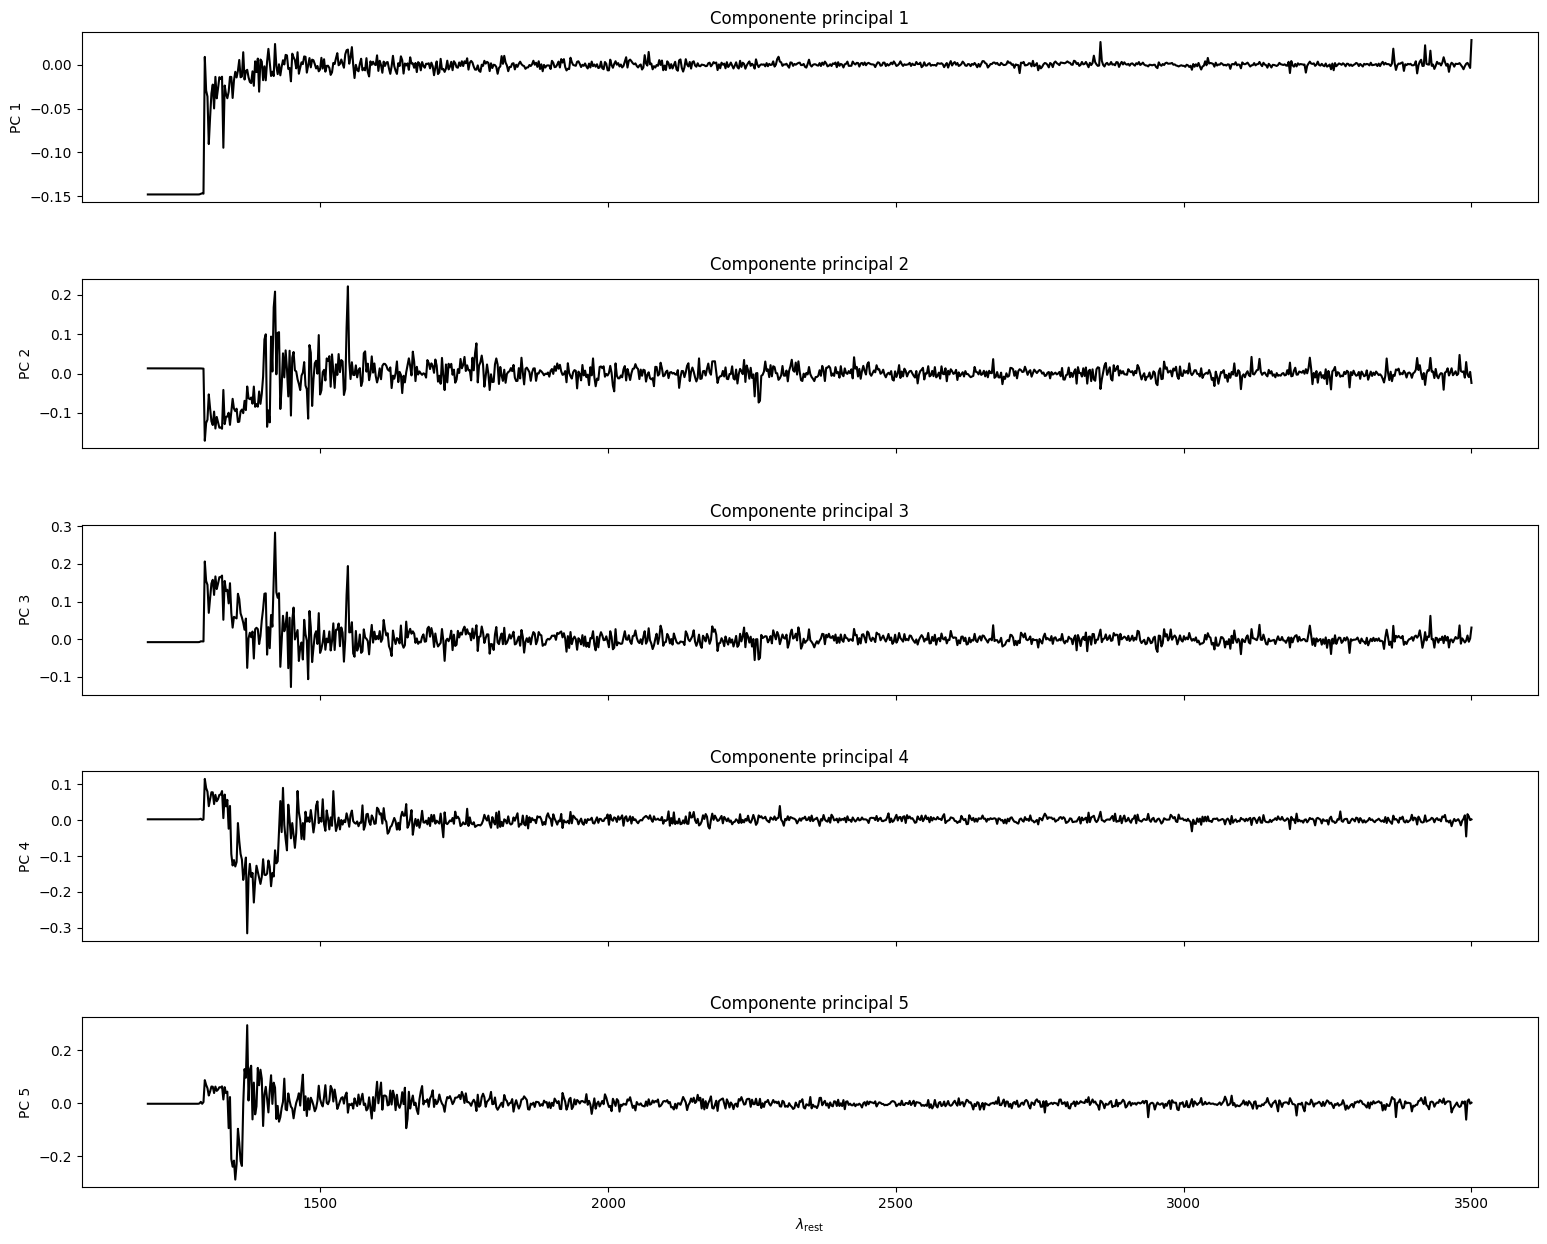

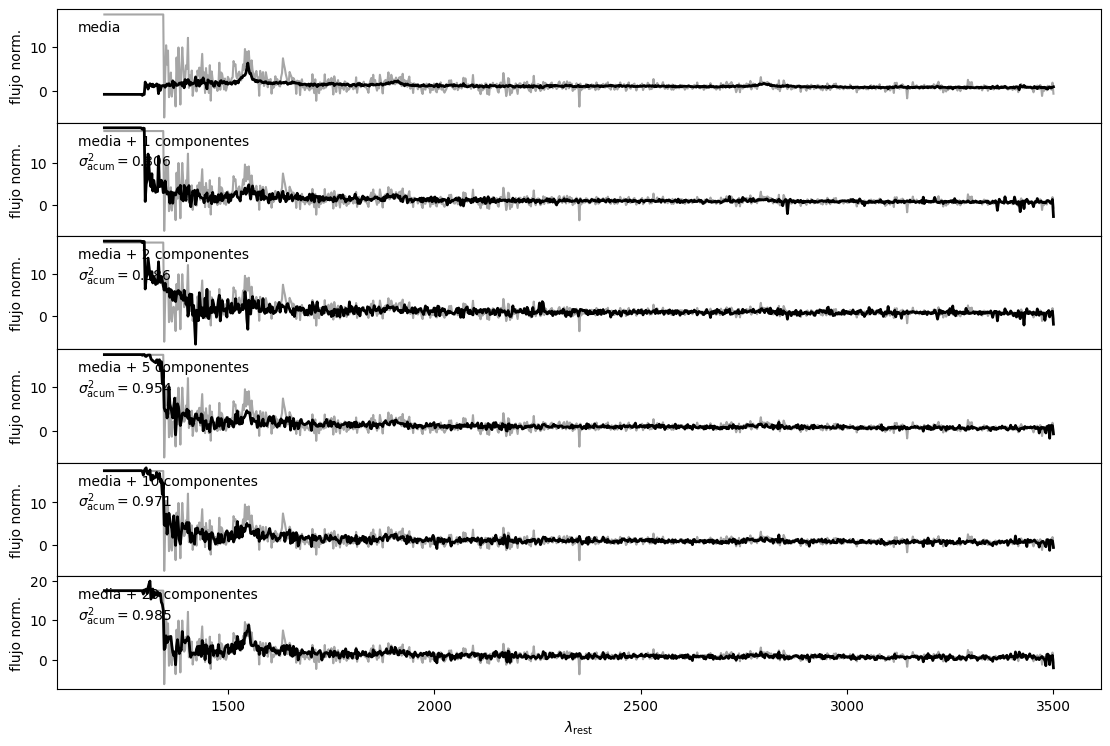

In [10]:
from sklearn.decomposition import PCA

n_spectra_pca = 100
n_lambda = 1000
n_components = 20

lambda_grid = np.linspace(lambda_min, lambda_max, n_lambda)

spectra_list = []
redshift_list = []
targetid_list = []

n_obj = min(n_spectra_pca, len(targetid))

for jj in range(n_obj):

    print(f"Procesando objeto {jj + 1}/{n_obj}")

    res = recuperar_espectro(
        specid=targetid[jj],
        inc=inc,
        dataset='DESI-DR1',
        max_intentos=max_intentos,
        pausa=pausa
    )

    if res is None:
        continue

    try:
        records = res.records

        if len(records) == 0:
            continue

        redshift = records[0].redshift
        lam_obs = np.array(records[0].wavelength)
        flam_obs = np.array(records[0].flux)

        lam_rest = lam_obs / (1.0 + redshift)
        flam_rest = flam_obs

        mask = (
            np.isfinite(lam_rest) &
            np.isfinite(flam_rest) &
            (lam_rest >= lambda_min) &
            (lam_rest <= lambda_max)
        )

        if np.sum(mask) < 10:
            continue

        lam_use = lam_rest[mask]
        flam_use = flam_rest[mask]

        order = np.argsort(lam_use)
        lam_use = lam_use[order]
        flam_use = flam_use[order]

        flam_interp = np.interp(lambda_grid, lam_use, flam_use)

        norm = np.median(flam_interp)

        if not np.isfinite(norm) or norm == 0:
            continue

        flam_interp = flam_interp / norm

        spectra_list.append(flam_interp)
        redshift_list.append(redshift)
        targetid_list.append(targetid[jj])

    except Exception as e:
        print(f"Falló el procesamiento del objeto {jj}")
        print(type(e).__name__, e)

spectra_matrix = np.array(spectra_list)
redshift_array = np.array(redshift_list)
targetid_array = np.array(targetid_list)

print("Forma de la matriz de espectros:")
print(spectra_matrix.shape)

if len(spectra_matrix) == 0:
    print("No se pudo construir la matriz de espectros.")

else:

    n_components_eff = min(n_components, len(spectra_matrix), spectra_matrix.shape[1])

    pca = PCA(n_components=n_components_eff)
    pca.fit(spectra_matrix)

    components = pca.components_
    mean_spectrum = pca.mean_
    coefficients = pca.transform(spectra_matrix)

    evals = pca.explained_variance_ratio_
    evals_cs = np.cumsum(evals)

    print("Varianza explicada:")
    print(evals)

    print("Varianza acumulada:")
    print(evals_cs)

  
    n_comp_plot = min(5, n_components_eff)

    fig, ax = plt.subplots(n_comp_plot, 1, figsize=(16, 3*n_comp_plot), sharex=True)

    if n_comp_plot == 1:
        ax = [ax]

    for i in range(n_comp_plot):
        ax[i].plot(lambda_grid, components[i], color='k')
        ax[i].set_ylabel(f"PC {i+1}")
        ax[i].set_title(f"Componente principal {i+1}")

    ax[-1].set_xlabel(r'$\lambda_{\rm rest}$')
    fig.subplots_adjust(left=0.07, right=0.98, hspace=0.45)
    plt.show()

    idx = 0

    spec = spectra_matrix[idx]
    coeff = coefficients[idx]

    componentes_a_usar = [0, 1, 2, 5, 10, 20]
    componentes_a_usar = [n for n in componentes_a_usar if n <= n_components_eff]

    fig = plt.figure(figsize=(12, 8))
    fig.subplots_adjust(hspace=0, top=0.95, bottom=0.1, left=0.10, right=0.97)

    for i, n in enumerate(componentes_a_usar):

        ax = fig.add_subplot(len(componentes_a_usar), 1, i + 1)

        if n == 0:
            reconstruction = mean_spectrum
            text = "media"
        else:
            reconstruction = mean_spectrum + np.dot(coeff[:n], components[:n])
            text = f"media + {n} componentes"
            text += "\n"
            text += r"$\sigma^2_{\rm acum} = %.3f$" % evals_cs[n - 1]

        ax.plot(lambda_grid, spec, color='gray', alpha=0.7)
        ax.plot(lambda_grid, reconstruction, color='k', lw=2)

        ax.set_ylabel("flujo norm.")

        if i < len(componentes_a_usar) - 1:
            ax.xaxis.set_major_formatter(plt.NullFormatter())

        ax.text(0.02, 0.90, text, ha='left', va='top', transform=ax.transAxes)

    fig.axes[-1].set_xlabel(r'$\lambda_{\rm rest}$')
    plt.show()

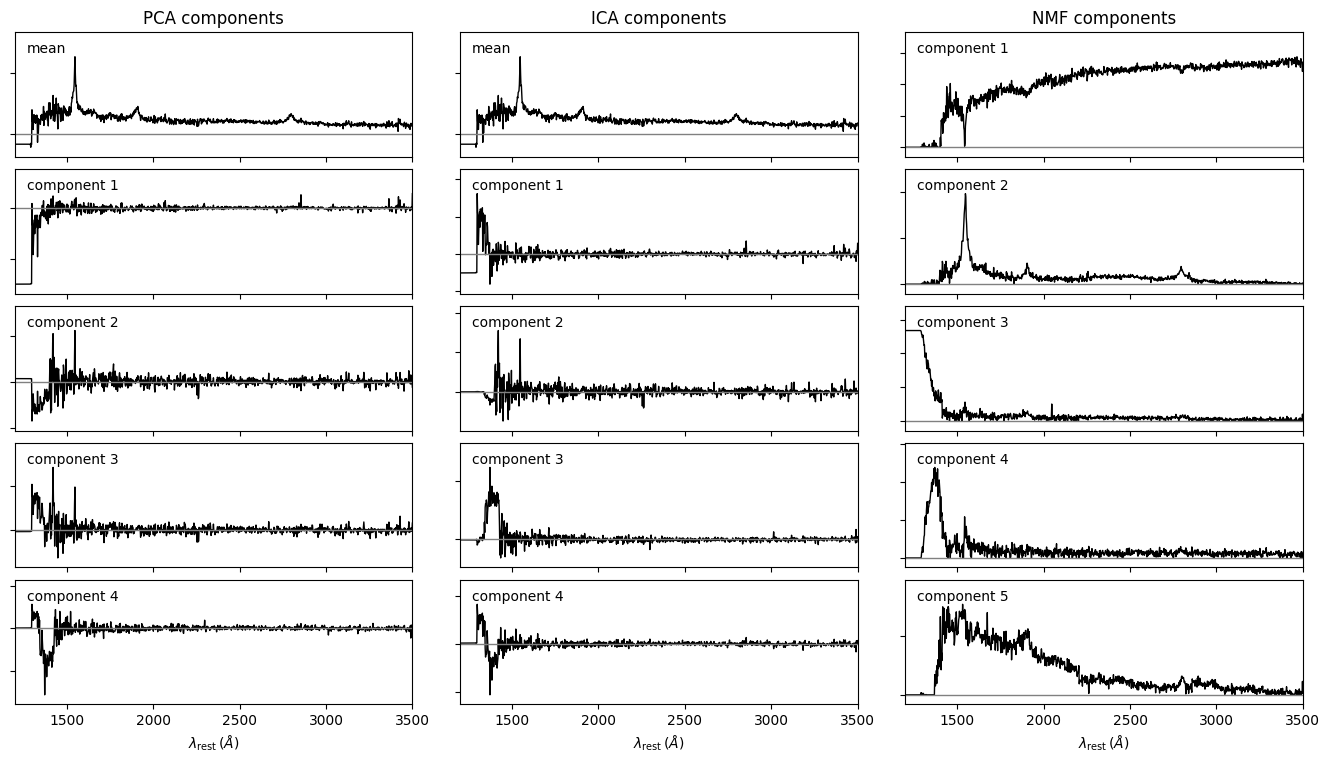

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, FastICA, NMF

n_components = 5

spectra = spectra_matrix.copy()
wavelengths = lambda_grid.copy()

spec_mean = spectra.mean(axis=0)

pca = PCA(n_components=n_components - 1, random_state=0, svd_solver='randomized')
pca.fit(spectra)

pca_comp = np.vstack([
    spec_mean,
    pca.components_
])

ica = FastICA(
    n_components=n_components - 1,
    random_state=0,
    max_iter=3000,
    tol=1e-4
)

ica_sources = ica.fit_transform(spectra)
ica_comp = np.vstack([
    spec_mean,
    ica.components_
])

spectra_nmf = spectra.copy()

spectra_nmf[~np.isfinite(spectra_nmf)] = 0.0

low = np.percentile(spectra_nmf, 1)
high = np.percentile(spectra_nmf, 99)

spectra_nmf = np.clip(spectra_nmf, low, high)

spectra_nmf = spectra_nmf - spectra_nmf.min(axis=1, keepdims=True)

norm = np.median(spectra_nmf, axis=1, keepdims=True)

norm[~np.isfinite(norm)] = 1.0
norm[norm == 0] = 1.0

spectra_nmf = spectra_nmf / norm
spectra_nmf = spectra_nmf + 1e-8

nmf = NMF(
    n_components=n_components,
    random_state=0,
    init='nndsvda',
    max_iter=5000
)

nmf.fit(spectra_nmf)

nmf_comp = nmf.components_

decompositions = [pca_comp, ica_comp, nmf_comp]
titles = ['PCA components', 'ICA components', 'NMF components']

fig = plt.figure(figsize=(14, 8))

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    wspace=0.12,
    bottom=0.08,
    top=0.92,
    hspace=0.10
)

for i, comp in enumerate(decompositions):

    for j in range(n_components):

        ax = fig.add_subplot(n_components, 3, 3*j + 1 + i)

        ax.plot(wavelengths, comp[j], '-k', lw=1)

        ax.plot(
            [lambda_min, lambda_max],
            [0, 0],
            '-',
            c='gray',
            lw=1
        )

        ax.set_xlim(lambda_min, lambda_max)

        if j < n_components - 1:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        else:
            ax.set_xlabel(r'$\lambda_{\rm rest}\,(\AA)$')

        ax.yaxis.set_major_formatter(plt.NullFormatter())

        if j == 0:
            ax.set_title(titles[i])

        if titles[i].startswith('PCA') or titles[i].startswith('ICA'):
            if j == 0:
                label = 'mean'
            else:
                label = f'component {j}'
        else:
            label = f'component {j + 1}'

        ax.text(
            0.03,
            0.92,
            label,
            transform=ax.transAxes,
            ha='left',
            va='top'
        )

        ylim = ax.get_ylim()
        dy = 0.05 * (ylim[1] - ylim[0])
        ax.set_ylim(ylim[0] - dy, ylim[1] + 4*dy)

plt.show()